# Analisi dei goal

Notebook dedicato a **come vengono scelti i goal** e a quanto ogni maze
risulta "difficile" secondo l'indice di detour usato dal piazzamento.

I dati sorgente sono i maze in `mazes/txt/`; il piazzamento dei goal è
deterministico (vedi `src/goal_placement.py`), quindi non servono i log
delle run per questa analisi.

## Setup

Import dei moduli `src` (parsing dei maze, piazzamento dei goal) e di
numpy/matplotlib/seaborn.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.parser.maze_parser import parse_maze
from src.goal_placement import scenario_goals

MAZES_DIR = REPO_ROOT / "mazes" / "txt"
START = (0, 0)

### Come vengono scelti i goal — heatmap dei punteggi

Per un maze a scelta (impostabile nella cella sotto) si mostrano, come **heatmap
seaborn**, le mappe di punteggio che `place_goals` usa per scegliere i goal — una
heatmap per ogni goal, così si vede a colpo d'occhio **quale cella viene presa a
ogni passo**.

Ogni heatmap è la mappa di punteggio il cui **massimo** (cella evidenziata in
verde) è il goal selezionato a quel passo:
1. **goal 1** → detour dalla partenza;
2. **goal k (k ≥ 2)** → minimo cella-per-cella dei detour da partenza e da tutti i
   goal già piazzati; il suo massimo è il goal *k*.

I goal scelti nei passi precedenti restano segnati (contorno grigio) per seguire
l'accumulo. Le celle vuote sono non candidabili (la partenza o celle
irraggiungibili). L'origine `(0,0)` è in **basso a sinistra**.

> Lo scenario classico *k = 1* è saltato di proposito: il goal è fisso al centro del
> maze `(w // 2 - 1, h // 2 - 1)` e non deriva dalle matrici di detour, quindi non
> compare in questa sequenza.

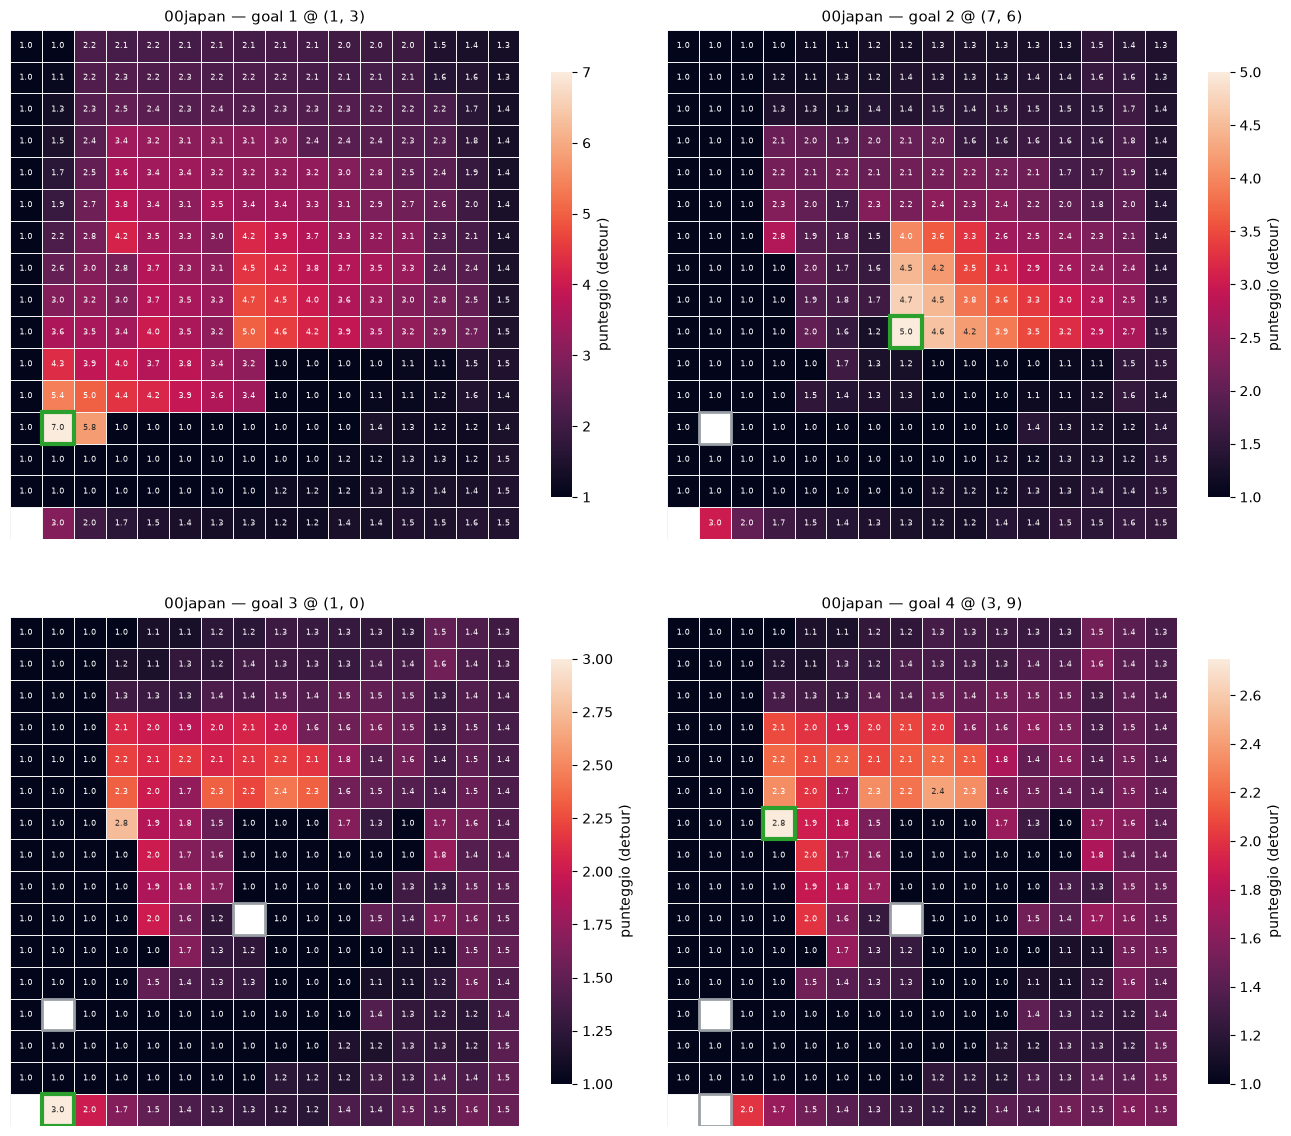

In [2]:
import seaborn as sns

from src.goal_placement import (
    bfs_distance_map, detour_map, argmax_cell, _combine_min,
)


def goal_score_panels(wall_matrix, width, height, start, k):
    """Mappa di punteggio che seleziona ogni goal 1..k di place_goals.

    Restituisce una lista di (i, score_map, goal, prev_goals): al passo i la
    score_map è quella il cui argmax è `goal`; prev_goals sono i goal scelti ai
    passi precedenti (per contestualizzare l'accumulo).
    """
    det_start = detour_map(bfs_distance_map(wall_matrix, width, height, start),
                           start, width, height)
    det_maps = [det_start]
    excluded = {start}
    chosen = []
    panels = []
    for i in range(1, k + 1):
        score_map = det_start if len(det_maps) == 1 else _combine_min(det_maps, width, height)
        goal, _ = argmax_cell(score_map, width, height, excluded)
        panels.append((i, score_map, goal, list(chosen)))
        excluded.add(goal)
        chosen.append(goal)
        det_maps.append(detour_map(bfs_distance_map(wall_matrix, width, height, goal),
                                   goal, width, height))
    return panels


def show_heatmap(ax, score_map, goal, prev_goals, title):
    """Heatmap seaborn della mappa di punteggio; goal scelto in verde, i goal
    dei passi precedenti con contorno grigio. y=0 in basso."""
    m = np.array(score_map, dtype=float)
    h, w = m.shape
    flip = m[::-1]                       # riga 0 (y=0) va in basso
    mask = np.isnan(flip)
    labels = np.where(mask, "", np.round(flip, 1).astype("U8"))
    sns.heatmap(flip, ax=ax, cmap="rocket", mask=mask,
                annot=labels, fmt="", annot_kws={"fontsize": 6},
                cbar=True, cbar_kws={"shrink": .7, "label": "punteggio (detour)"},
                linewidths=.5, linecolor="#f2f2f2",
                square=True, xticklabels=False, yticklabels=False)
    for px, py in prev_goals:            # goal gia' piazzati: contorno grigio
        ax.add_patch(plt.Rectangle((px, h - 1 - py), 1, 1, fill=False,
                                   edgecolor="#9aa0a6", lw=2))
    gx, gy = goal                        # goal scelto a questo passo: verde
    ax.add_patch(plt.Rectangle((gx, h - 1 - gy), 1, 1, fill=False,
                               edgecolor="#2ca02c", lw=3))
    ax.set_title(title, fontsize=11)


# --- scegli qui il maze e quanti goal ricostruire (k >= 2) ---
MAZE = "00japan"
K = 4

wm, w, h = parse_maze(str(MAZES_DIR / f"{MAZE}.txt"))
panels = goal_score_panels(wm, w, h, START, K)

ncols = 2
nrows = (len(panels) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * (0.32 * w + 1.5), nrows * (0.32 * h + 1)))
for ax, (i, score_map, goal, prev_goals) in zip(axes.flat, panels):
    show_heatmap(ax, score_map, goal, prev_goals,
                 f"{MAZE} — goal {i} @ {goal}")
for ax in axes.flat[len(panels):]:       # spegni eventuali riquadri in eccesso
    ax.axis("off")
fig.tight_layout()
plt.show()

### Maze più difficili per scenario — indice di detour

Per ogni scenario (`k = 1..4` goal) classifichiamo i maze in base alla
**difficoltà dei goal scelti**, misurata dall'indice di detour
(`d_BFS / d_Manhattan`) restituito da `scenario_goals`.

La tabella è **ordinata per detour medio** dei goal dello scenario; la
colonna `detour_totale` (somma) è riportata a fianco come misura
complementare. Nota: dentro uno stesso scenario tutti i maze hanno lo
stesso numero di goal, quindi la somma è proporzionale alla media e non
cambierebbe l'ordinamento — la teniamo solo per espressività.

> Per `k = 1` il goal è il centro fisso del maze: c'è un solo valore,
> quindi media e somma coincidono. `n_goal` < k segnala i rari maze in cui
> il piazzamento esaurisce le celle candidabili prima di piazzare k goal.

In [3]:
import pandas as pd
from IPython.display import display

TOP_N = 5
K_MAX = 4
MAZE_FILES = sorted(MAZES_DIR.glob("*.txt"))


def scenario_detour_table(k):
    """Un record per maze: detour medio e totale dei goal dello scenario k."""
    rows = []
    for path in MAZE_FILES:
        wm, w, h = parse_maze(str(path))
        try:
            goals = scenario_goals(wm, w, h, START, k)
        except ValueError:
            continue                       # scenario non valido per questo maze
        detours = [d for _, d in goals]
        if not detours:
            continue
        rows.append({
            "maze":           path.stem,
            "n_goal":         len(detours),
            "detour_medio":   float(np.mean(detours)),
            "detour_totale":  float(np.sum(detours)),
        })
    df = pd.DataFrame(rows).sort_values("detour_medio", ascending=False)
    return df.reset_index(drop=True)


for k in range(1, K_MAX + 1):
    top = scenario_detour_table(k).head(TOP_N).copy()
    top.index = range(1, len(top) + 1)          # rank 1..5
    print(f"\n=== Scenario k={k} — top {TOP_N} maze per detour medio ===")
    display(top.round(3))


=== Scenario k=1 — top 5 maze per detour medio ===


,maze,n_goal,detour_medio,detour_totale
1,zigzag,1,17.143,17.143
2,2016apec,1,9.429,9.429
3,2013apec,1,9.429,9.429
4,2017apec,1,7.714,7.714
5,2013japan,1,7.571,7.571



=== Scenario k=2 — top 5 maze per detour medio ===


,maze,n_goal,detour_medio,detour_totale
1,2013japan,2,33.154,66.308
2,zigzag,2,30.333,60.667
3,j1,2,25.200,50.400
4,2014japan,2,23.750,47.500
5,89sina1,2,21.333,42.667



=== Scenario k=3 — top 5 maze per detour medio ===


,maze,n_goal,detour_medio,detour_totale
1,zigzag,3,24.222,72.667
2,2013japan,3,22.969,68.908
3,j1,3,18.345,55.036
4,2014japan,3,17.389,52.167
5,89sina1,3,15.343,46.030



=== Scenario k=4 — top 5 maze per detour medio ===


,maze,n_goal,detour_medio,detour_totale
1,zigzag,4,19.250,77.000
2,2013japan,4,17.852,71.408
3,j1,4,14.592,58.370
4,2014japan,4,13.649,54.595
5,89sina1,4,12.258,49.030


#### Versione markdown per la relazione

Le stesse top-5 per scenario in formato Markdown, pronte da incollare nel
report. La cella stampa il testo grezzo (copiabile) e ne mostra l'anteprima
renderizzata.

In [4]:
from IPython.display import Markdown


def scenario_table_md(df, k, top_n=TOP_N):
    """Top-N maze dello scenario k come tabella Markdown (una riga per rank)."""
    top = df.head(top_n).reset_index(drop=True)
    lines = [
        f"#### Scenario k={k} \u2014 top {top_n} maze per detour medio",
        "",
        "| # | maze | n_goal | detour medio | detour totale |",
        "|--:|------|-------:|-------------:|--------------:|",
    ]
    for rank, r in enumerate(top.itertuples(index=False), start=1):
        lines.append(
            f"| {rank} | {r.maze} | {r.n_goal} | "
            f"{r.detour_medio:.3f} | {r.detour_totale:.3f} |"
        )
    return "\n".join(lines)


md_report = "\n\n".join(
    scenario_table_md(scenario_detour_table(k), k) for k in range(1, K_MAX + 1)
)
print(md_report)                    # testo grezzo, copiabile nella relazione
display(Markdown(md_report))        # anteprima renderizzata

#### Scenario k=1 — top 5 maze per detour medio

| # | maze | n_goal | detour medio | detour totale |
|--:|------|-------:|-------------:|--------------:|
| 1 | zigzag | 1 | 17.143 | 17.143 |
| 2 | 2016apec | 1 | 9.429 | 9.429 |
| 3 | 2013apec | 1 | 9.429 | 9.429 |
| 4 | 2017apec | 1 | 7.714 | 7.714 |
| 5 | 2013japan | 1 | 7.571 | 7.571 |

#### Scenario k=2 — top 5 maze per detour medio

| # | maze | n_goal | detour medio | detour totale |
|--:|------|-------:|-------------:|--------------:|
| 1 | 2013japan | 2 | 33.154 | 66.308 |
| 2 | zigzag | 2 | 30.333 | 60.667 |
| 3 | j1 | 2 | 25.200 | 50.400 |
| 4 | 2014japan | 2 | 23.750 | 47.500 |
| 5 | 89sina1 | 2 | 21.333 | 42.667 |

#### Scenario k=3 — top 5 maze per detour medio

| # | maze | n_goal | detour medio | detour totale |
|--:|------|-------:|-------------:|--------------:|
| 1 | zigzag | 3 | 24.222 | 72.667 |
| 2 | 2013japan | 3 | 22.969 | 68.908 |
| 3 | j1 | 3 | 18.345 | 55.036 |
| 4 | 2014japan | 3 | 17.389 | 52.167 |
| 5 | 89s

#### Scenario k=1 — top 5 maze per detour medio

| # | maze | n_goal | detour medio | detour totale |
|--:|------|-------:|-------------:|--------------:|
| 1 | zigzag | 1 | 17.143 | 17.143 |
| 2 | 2016apec | 1 | 9.429 | 9.429 |
| 3 | 2013apec | 1 | 9.429 | 9.429 |
| 4 | 2017apec | 1 | 7.714 | 7.714 |
| 5 | 2013japan | 1 | 7.571 | 7.571 |

#### Scenario k=2 — top 5 maze per detour medio

| # | maze | n_goal | detour medio | detour totale |
|--:|------|-------:|-------------:|--------------:|
| 1 | 2013japan | 2 | 33.154 | 66.308 |
| 2 | zigzag | 2 | 30.333 | 60.667 |
| 3 | j1 | 2 | 25.200 | 50.400 |
| 4 | 2014japan | 2 | 23.750 | 47.500 |
| 5 | 89sina1 | 2 | 21.333 | 42.667 |

#### Scenario k=3 — top 5 maze per detour medio

| # | maze | n_goal | detour medio | detour totale |
|--:|------|-------:|-------------:|--------------:|
| 1 | zigzag | 3 | 24.222 | 72.667 |
| 2 | 2013japan | 3 | 22.969 | 68.908 |
| 3 | j1 | 3 | 18.345 | 55.036 |
| 4 | 2014japan | 3 | 17.389 | 52.167 |
| 5 | 89sina1 | 3 | 15.343 | 46.030 |

#### Scenario k=4 — top 5 maze per detour medio

| # | maze | n_goal | detour medio | detour totale |
|--:|------|-------:|-------------:|--------------:|
| 1 | zigzag | 4 | 19.250 | 77.000 |
| 2 | 2013japan | 4 | 17.852 | 71.408 |
| 3 | j1 | 4 | 14.592 | 58.370 |
| 4 | 2014japan | 4 | 13.649 | 54.595 |
| 5 | 89sina1 | 4 | 12.258 | 49.030 |